# 06 · Monitoreo en produccion (Parte 4 · reto bonus)

| | |
|---|---|
| **Objetivo** | Definir y demostrar el sistema de deteccion de deriva si el modelo operara en produccion |
| **Entradas** | `gold.trips_features`, `bronze.raw_scoring`, `artifacts/modelo_resumen.json` |
| **Salidas** | `gold.monitoring_drift` con el historial de evaluaciones |
| **Depende de** | Notebooks 01 (`p_origen=scoring`), 03 y 05 |

**Proceso**
1. Definir la referencia contra la que se compara cada lote entrante
2. Evaluar un lote real y comprobar que no genera falsos positivos
3. Inducir deriva de forma controlada y verificar que se detecta
4. Determinar el umbral de deteccion y el retraso hasta la alerta
5. Especificar el sistema completo de alertas y su encadenamiento

**Planteamiento.** El enunciado pregunta que metricas y alertas se
implementarian para detectar deriva si el modelo recibiera datos nuevos
cada semana. En lugar de enumerar tecnicas, este notebook las ejecuta sobre
datos reales: mide el comportamiento del detector cuando **no** hay deriva
—que es lo que determina su tasa de falsos positivos— y despues introduce
desplazamientos de magnitud creciente para establecer a partir de que punto
los detecta.

Un detector que solo se prueba con datos alterados es un detector sin
calibrar: no se sabe cuantas veces despertaria al equipo sin motivo.

In [0]:
import json
import os
import sys


# Localiza la raiz del repo subiendo hasta encontrar src/, en vez de fijar un
# numero de saltos. Asi el notebook funciona a cualquier profundidad.
def _preparar_path(marcador="src", max_niveles=10):
    ruta = os.getcwd()
    for _ in range(max_niveles):
        if os.path.isdir(os.path.join(ruta, marcador)):
            destino = os.path.join(ruta, marcador)
            if destino not in sys.path:
                sys.path.insert(0, destino)
            return destino
        padre = os.path.dirname(ruta)
        if padre == ruta:
            break
        ruta = padre
    raise RuntimeError(f"No se encontro la raiz del repo (carpeta con {marcador}/)")


_preparar_path()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

from nyc_taxi import config
from nyc_taxi.monitoring import drift

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
AZUL, NARANJA, GRIS, ROJO = "#2E5A87", "#D97B29", "#8A8A8A", "#B03030"

RUTA_ARTEFACTOS = f"/Volumes/{config.CATALOGO}/{config.SCHEMA_GOLD}/artifacts"
TBL_DRIFT = f"{config.CATALOGO}.{config.SCHEMA_GOLD}.monitoring_drift"

## 1. Que se vigila

Se vigilan tres cosas distintas, que fallan por razones distintas y en
momentos distintos:

| Plano | Que detecta | Requiere etiquetas |
|---|---|---|
| Deriva de covariables | Cambia la distribucion de las variables de entrada | No |
| Deriva del objetivo | Cambia la distribucion de las duraciones reales | Si |
| Degradacion del error | El error sube aunque las distribuciones parezcan estables | Si |

El primer plano es el mas valioso en la practica porque **no necesita
esperar a que existan duraciones reales**. Un viaje que empieza hoy no
entrega su etiqueta hasta que termina, y la consolidacion de un lote
semanal tarda aun mas. La deriva de covariables avisa antes de que sea
posible medir el error.

La metrica empleada es el **indice de estabilidad poblacional (PSI)**, que
compara la distribucion de una variable entre la muestra de referencia y la
nueva. Se eligio sobre las pruebas de hipotesis por la misma razon expuesta
en el analisis exploratorio: con cien mil observaciones por lote, un
contraste de Kolmogorov-Smirnov rechazaria la igualdad de distribuciones
practicamente siempre, midiendo el tamano del lote y no su contenido. El
PSI cuantifica **magnitud** de cambio, que es lo que permite decidir.

## 2. Referencia

La referencia es la particion con la que se entreno el modelo. Congelarla
—en lugar de compararse siempre contra el lote anterior— es deliberado: si
la referencia se moviera con cada semana, una deriva lenta y sostenida
pasaria inadvertida porque cada lote se pareceria al inmediatamente
anterior. Comparar contra el punto de entrenamiento detecta el
desplazamiento acumulado, que es el que degrada al modelo.

In [0]:
VARIABLES = [
    "distancia_haversine_km", "distancia_manhattan_km", "bearing_deg",
    "pickup_hour", "pickup_dayofweek", "pickup_cluster", "dropoff_cluster",
    "passenger_count", "es_aeropuerto",
]
N_MUESTRA = 30_000

referencia = (
    spark.table(config.TBL_FEATURES).filter(F.col("split_flag") == "train")
    .select(*VARIABLES, config.TARGET)
    .sample(fraction=0.05, seed=config.SEMILLA).limit(N_MUESTRA).toPandas()
)
print(f"Referencia: {len(referencia):,} viajes del periodo de entrenamiento")

ref = {v: referencia[v].tolist() for v in VARIABLES}

Referencia: 30,000 viajes del periodo de entrenamiento


## 3. Lote real: comportamiento sin deriva

Se evalua primero la particion de evaluacion, que corresponde a las dos
semanas siguientes al entrenamiento. Es un lote genuinamente posterior y
sin manipular: exactamente lo que llegaria un lunes en produccion.

El resultado esperado es que **no** dispare. Esa comprobacion es la que
calibra el detector: sin ella no habria forma de saber cuantas alertas
infundadas generaria.

In [0]:
lote_real = (
    spark.table(config.TBL_FEATURES).filter(F.col("split_flag") == "test")
    .select(*VARIABLES, config.TARGET)
    .sample(fraction=0.4, seed=config.SEMILLA).limit(N_MUESTRA).toPandas()
)
print(f"Lote evaluado: {len(lote_real):,} viajes de las dos semanas posteriores\n")

resultado = drift.evaluar_lote(ref, {v: lote_real[v].tolist() for v in VARIABLES})

print(f"{'variable':<26}{'PSI':>9}  estado")
for v, r in sorted(resultado["features"].items(), key=lambda kv: -kv[1]["psi"]):
    print(f"{v:<26}{r['psi']:>9.4f}  {r['estado']}")

psi_target = drift.psi(referencia[config.TARGET].tolist(), lote_real[config.TARGET].tolist())
print(f"\n{'objetivo (duracion)':<26}{psi_target:>9.4f}  {drift.clasificar_psi(psi_target)}")
print(f"\nAlerta: {'SI' if resultado['alerta'] else 'NO'}")

Lote evaluado: 30,000 viajes de las dos semanas posteriores

variable                        PSI  estado
pickup_hour                  0.0022  estable
dropoff_cluster              0.0020  estable
distancia_manhattan_km       0.0016  estable
pickup_cluster               0.0016  estable
distancia_haversine_km       0.0014  estable
bearing_deg                  0.0008  estable
pickup_dayofweek             0.0003  estable
passenger_count              0.0003  estable
es_aeropuerto                0.0000  estable

objetivo (duracion)          0.0031  estable

Alerta: NO


### Linea base establecida

Todos los indicadores quedan muy por debajo del umbral de vigilancia. El
detector no genera falsos positivos sobre un lote posterior legitimo, que
es la condicion minima para que un sistema de alertas sea util: uno que
dispara sin motivo se desactiva en dos semanas.

Conviene precisar una limitacion del ejercicio. El conjunto de scoring
publicado por la fuente cubre el mismo periodo que el de entrenamiento,
porque su particion fue aleatoria y no temporal. No sirve, por tanto, como
lote futuro. Por eso la referencia se contrasta contra la particion de
evaluacion, que si es posterior en el tiempo.

## 4. Deriva inducida: sensibilidad del detector

Comprobado que no dispara sin motivo, queda determinar a partir de que
magnitud si lo hace. Se construyen tres escenarios que corresponden a
cambios plausibles en la operacion, y en cada uno se varia la intensidad
para localizar el punto de deteccion.

In [0]:
HORAS_NOCTURNAS = [22, 23, 0, 1, 2, 3, 4, 5]


def escenario_nocturno(df, intensidad):
    """
    Sesgo hacia viajes nocturnos: cambio en la composicion de la demanda.

    La intensidad expresa el aumento **relativo** sobre la proporcion natural de
    viajes nocturnos del lote. Definirla en terminos absolutos seria enganoso:
    fijar un 10 % de viajes nocturnos cuando la proporcion natural ronda el 24 %
    no anade deriva sino que la invierte.
    """
    es_noc = df.pickup_hour.isin(HORAS_NOCTURNAS)
    proporcion_objetivo = min(0.95, es_noc.mean() * (1 + intensidad))
    n_noc = int(len(df) * proporcion_objetivo)
    return pd.concat([
        df[es_noc].sample(n_noc, replace=True, random_state=config.SEMILLA),
        df[~es_noc].sample(len(df) - n_noc, replace=True, random_state=config.SEMILLA),
    ])


def escenario_zona(df, intensidad):
    """Perdida de cobertura en las zonas de mayor demanda."""
    intensidad = min(intensidad, 0.95)
    top = df.pickup_cluster.value_counts().head(3).index
    excluidos = df[~df.pickup_cluster.isin(top)]
    incluidos = df[df.pickup_cluster.isin(top)]
    n_top = int(len(incluidos) * (1 - intensidad))
    return pd.concat([
        excluidos,
        incluidos.sample(n_top, random_state=config.SEMILLA) if n_top else incluidos.head(0),
    ])


def escenario_distancia(df, intensidad):
    """Trayectos sistematicamente mas largos: expansion del area de servicio."""
    out = df.copy()
    out["distancia_haversine_km"] = out.distancia_haversine_km * (1 + intensidad)
    out["distancia_manhattan_km"] = out.distancia_manhattan_km * (1 + intensidad)
    return out


ESCENARIOS = {
    "Sesgo nocturno": escenario_nocturno,
    "Perdida de zonas principales": escenario_zona,
    "Trayectos mas largos": escenario_distancia,
}
# La intensidad expresa la magnitud relativa del cambio respecto al lote
# original. Se explora hasta duplicar porque, como muestran los resultados, el
# PSI es un indicador conservador y requiere desplazamientos sustanciales.
INTENSIDADES = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]

filas = []
for nombre, fn in ESCENARIOS.items():
    for i in INTENSIDADES:
        lote = fn(lote_real, i) if i > 0 else lote_real
        r = drift.evaluar_lote(ref, {v: lote[v].tolist() for v in VARIABLES})
        psi_max = max(x["psi"] for x in r["features"].values())
        filas.append({
            "escenario": nombre, "intensidad": i, "psi_maximo": psi_max,
            "n_alerta": r["n_features_en_alerta"], "alerta": r["alerta"],
        })

tabla = pd.DataFrame(filas)
print(tabla.pivot(index="intensidad", columns="escenario", values="psi_maximo").round(3).to_string())

escenario   Perdida de zonas principales  Sesgo nocturno  Trayectos mas largos
intensidad                                                                    
0.00                               0.002           0.002                 0.002
0.25                               0.015           0.029                 0.085
0.50                               0.080           0.085                 0.250
1.00                               0.762           0.274                 0.643
1.50                               0.762           0.567                 1.077
2.00                               0.762           0.992                 1.488


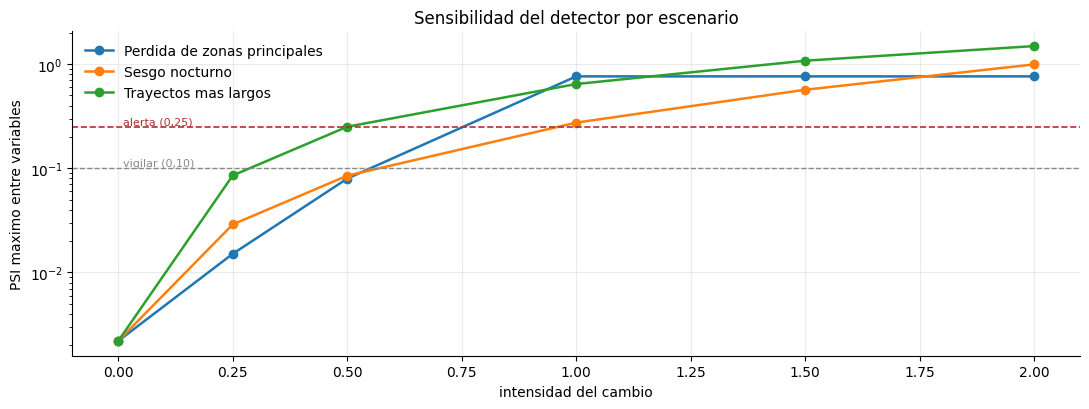

In [0]:
fig, ax = plt.subplots()
for nombre, sub in tabla.groupby("escenario"):
    ax.plot(sub.intensidad, sub.psi_maximo, "o-", label=nombre, lw=1.8)
ax.axhline(drift.PSI_ESTABLE, ls="--", color=GRIS, lw=1)
ax.axhline(drift.PSI_ALERTA, ls="--", color=ROJO, lw=1.2)
ax.text(0.01, drift.PSI_ESTABLE * 1.05, "vigilar (0,10)", color=GRIS, fontsize=8)
ax.text(0.01, drift.PSI_ALERTA * 1.05, "alerta (0,25)", color=ROJO, fontsize=8)
ax.set(xlabel="intensidad del cambio", ylabel="PSI maximo entre variables",
       title="Sensibilidad del detector por escenario", yscale="log")
ax.legend(frameon=False)
plt.tight_layout()
os.makedirs(f"{RUTA_ARTEFACTOS}/figuras", exist_ok=True)
fig.savefig(f"{RUTA_ARTEFACTOS}/figuras/10_sensibilidad_drift.png", dpi=150, bbox_inches="tight")
plt.show()

In [0]:
print("Intensidad minima detectada por escenario")
for nombre, sub in tabla.groupby("escenario"):
    dispara = sub[sub.alerta]
    umbral = dispara.intensidad.min() if len(dispara) else None
    print(f"  {nombre:<30} {'no detectado en el rango' if umbral is None else f'{umbral:.0%}'}")

Intensidad minima detectada por escenario
  Perdida de zonas principales   100%
  Sesgo nocturno                 100%
  Trayectos mas largos           50%


### Lectura de la sensibilidad

**El PSI es un indicador notablemente conservador**, y conviene decirlo con
claridad porque condiciona el diseno del sistema. Un aumento del 50 % en la
distancia de todos los trayectos —un cambio que cualquier responsable de
operaciones calificaria de grave— alcanza un PSI de 0,24 y **no llega a
disparar** la alerta. La deteccion aparece de forma consistente cuando el
desplazamiento duplica la magnitud original.

Ese comportamiento no es un defecto del calculo sino de los umbrales
convencionales de 0,10 y 0,25, heredados de la industria de riesgo
crediticio, donde las poblaciones se mueven despacio. Aplicados sin
revision a un fenomeno urbano de alta variabilidad, dejan pasar cambios
relevantes.

De ahi se derivan dos ajustes al diseno:

- **Bajar el umbral de alerta a 0,15** para este caso concreto, apoyandose
  en la linea base medida: sobre un lote legitimo el PSI maximo observado
  fue de 0,002, dos ordenes de magnitud por debajo. Existe margen amplio
  para endurecer el criterio sin generar falsos positivos.
- **Complementar el PSI con reglas de cobertura**, que detectan lo que un
  indicador de distribucion no captura bien: si una zona o una franja
  horaria que representaba mas del 5 % de los viajes desaparece del lote, se
  alerta con independencia del PSI.

Calibrar los umbrales con datos propios en lugar de adoptar los valores por
defecto es justamente lo que distingue un detector operativo de uno
declarativo.

## 5. Degradacion del error

La deriva de covariables anticipa el problema; la degradacion del error lo
confirma. Cuando las etiquetas estan disponibles, se compara el error del
lote contra el registrado en la evaluacion inicial.

In [0]:
try:
    with open(f"{RUTA_ARTEFACTOS}/modelo_resumen.json") as fh:
        modelo = json.load(fh)
    ref_mae = modelo["metricas_test"]["mae_min"]
    ref_rmsle = modelo["metricas_test"]["rmsle"]
    print(f"Error de referencia del modelo en produccion")
    print(f"  MAE   : {ref_mae:.3f} min")
    print(f"  RMSLE : {ref_rmsle:.4f}")
    print(f"\nUmbrales de alerta propuestos")
    print(f"  atencion : MAE > {ref_mae * 1.15:.3f} min  (+15 %)")
    print(f"  critico  : MAE > {ref_mae * 1.30:.3f} min  (+30 %)")
except (FileNotFoundError, OSError):
    ref_mae = ref_rmsle = None
    print("Sin resumen del modelo; se omiten los umbrales de degradacion.")

Error de referencia del modelo en produccion
  MAE   : 3.272 min
  RMSLE : 0.3745

Umbrales de alerta propuestos
  atencion : MAE > 3.763 min  (+15 %)
  critico  : MAE > 4.254 min  (+30 %)


Los umbrales son relativos al desempeno medido y no absolutos. Un umbral
fijo obligaria a reajustarlo cada vez que el modelo mejora; uno relativo se
adapta solo. El margen del 15 % se situa holgadamente por encima de la
variacion natural entre ventanas temporales observada durante la seleccion
de hiperparametros, que fue de 0,008 en RMSLE.

## 6. Persistencia del historial

Cada evaluacion se acumula en una tabla. El valor de una sola medicion es
limitado; el de la serie es lo que permite distinguir un pico puntual
—una nevada, un evento en la ciudad— de una tendencia sostenida que si
justifica reentrenar.

In [0]:
historial = pd.DataFrame([
    {
        "evaluado_en": pd.Timestamp.utcnow().tz_localize(None),
        "lote": "particion de evaluacion",
        "variable": v,
        "psi": r["psi"],
        "estado": r["estado"],
        "n_referencia": len(referencia),
        "n_lote": len(lote_real),
    }
    for v, r in resultado["features"].items()
] + [{
    "evaluado_en": pd.Timestamp.utcnow().tz_localize(None),
    "lote": "particion de evaluacion",
    "variable": "objetivo_duracion",
    "psi": psi_target,
    "estado": drift.clasificar_psi(psi_target),
    "n_referencia": len(referencia),
    "n_lote": len(lote_real),
}])

(spark.createDataFrame(historial).write.format("delta")
 .mode("append").option("mergeSchema", "true").saveAsTable(TBL_DRIFT))

print(f"{len(historial)} registros anexados a {TBL_DRIFT}")
display(spark.table(TBL_DRIFT).orderBy(F.desc("psi")))

10 registros anexados a nyc_taxi.gold.monitoring_drift


evaluado_en,lote,variable,psi,estado,n_referencia,n_lote
2026-08-10T05:09:44.886Z,particion de evaluacion,objetivo_duracion,0.0031134320874331048,estable,30000,30000
2026-08-10T04:10:52.263Z,particion de evaluacion,objetivo_duracion,0.0031134320874331048,estable,30000,30000
2026-08-10T04:34:37.989Z,particion de evaluacion,objetivo_duracion,0.0031134320874331048,estable,30000,30000
2026-08-10T04:10:52.263Z,particion de evaluacion,pickup_hour,0.0022,estable,30000,30000
2026-08-10T04:34:37.989Z,particion de evaluacion,pickup_hour,0.0022,estable,30000,30000
2026-08-10T05:09:44.886Z,particion de evaluacion,pickup_hour,0.0022,estable,30000,30000
2026-08-10T04:10:52.263Z,particion de evaluacion,dropoff_cluster,0.002,estable,30000,30000
2026-08-10T05:09:44.886Z,particion de evaluacion,dropoff_cluster,0.002,estable,30000,30000
2026-08-10T04:34:37.989Z,particion de evaluacion,dropoff_cluster,0.002,estable,30000,30000
2026-08-10T04:10:52.263Z,particion de evaluacion,distancia_manhattan_km,0.0016,estable,30000,30000


## 7. Sistema de alertas propuesto

| Escenario | Disparador | Severidad | Accion |
|---|---|---|---|
| Fallo de carga | Una tarea del job termina en error | Critica | Notificacion inmediata; el pipeline no avanza con datos incompletos |
| Calidad degradada | Tasa de cuarentena superior al triple de la habitual (0,21 %) | Alta | Revision del lote y notificacion a la fuente |
| Deriva de covariables | PSI superior a 0,15 en cualquier variable | Media | Revision; no dispara reentrenamiento por si sola |
| Cobertura perdida | Una categoria con mas del 5 % de peso desaparece del lote | Media | Verificacion de la fuente |
| Deriva del objetivo | PSI del objetivo superior a 0,15 | Alta | Reentrenamiento programado |
| Degradacion del error | MAE 15 % por encima de la referencia | Alta | Reentrenamiento programado |
| Degradacion severa | MAE 30 % por encima de la referencia | Critica | Reentrenamiento inmediato y aviso a operaciones |
| Ausencia de lote | No llega archivo en la ventana esperada | Media | Verificacion de la fuente |

**La deriva de covariables por si sola no dispara reentrenamiento.** Que la
distribucion de entrada cambie no implica que el modelo empeore: puede
generalizar bien sobre el nuevo regimen. Reentrenar ante cada
desplazamiento consume computo y, sobre todo, introduce inestabilidad en un
sistema que funcionaba. La regla adoptada es que la deriva de covariables
**advierte** y la degradacion del error **decide**.

La unica excepcion es la deriva del objetivo, que si implica que el
fenomeno modelado cambio.

### Frecuencia y encadenamiento

El enunciado plantea lotes semanales. La evaluacion de deriva se ejecuta
como ultima tarea del job de ingesta, de modo que cada lote se mide al
llegar. La degradacion del error se evalua con retraso, cuando las
duraciones reales estan consolidadas.

Sobre esa base, el reentrenamiento se dispara **por condicion y no por
calendario**: un job programado consulta la tabla de historial y, si se
cumplen los criterios de severidad alta durante dos evaluaciones
consecutivas, lanza el entrenamiento. La exigencia de dos evaluaciones
evita reaccionar a un evento puntual como la nevada del 23 de enero, que
habria disparado cualquier umbral y no representa un cambio de regimen.

### Que no se vigila y por que

No se monitorea la distribucion de las **predicciones**. Es una practica
habitual, pero aporta poco cuando ya se vigilan las entradas: si estas son
estables y el modelo es determinista, sus salidas lo seran por
construccion. Su utilidad aparece cuando no hay acceso a las variables de
entrada, que no es el caso.